Models in CSV: <StringArray>
['deepseek-r1-distill-8b']
Length: 1, dtype: str


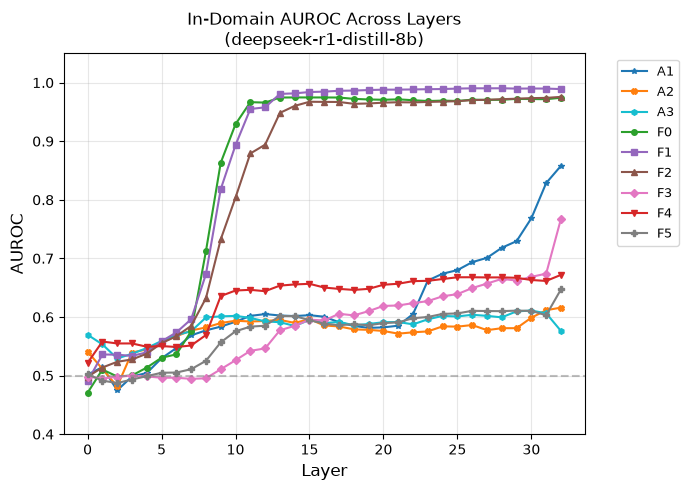

✓ Graph 1 saved: auroc_by_layer.png


In [4]:
import sys
import subprocess
import pandas as pd

# Install matplotlib if missing

import matplotlib.pyplot as plt

csv_path = "results_database.csv"
df = pd.read_csv(csv_path)

# Filter to in-domain only
in_domain = df[df['train_task'] == df['test_task']].copy()

style_map = {
    "F0": {"color": "#2ca02c", "marker": "o"},
    "F1": {"color": "#9467bd", "marker": "s"},
    "F2": {"color": "#8c564b", "marker": "^"},
    "F3": {"color": "#e377c2", "marker": "D"},
    "F4": {"color": "#d62728", "marker": "v"},
    "F5": {"color": "#7f7f7f", "marker": "P"},
    "A1": {"color": "#1f77b4", "marker": "*"},
    "A2": {"color": "#ff7f0e", "marker": "X"},
    "A3": {"color": "#17becf", "marker": "h"},
}

# Plot one line per model
models = df['model'].unique()
print(f"Models in CSV: {models}")

fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5), sharey=True)

# Handle single model case
if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models):
    model_data = in_domain[in_domain['model'] == model_name]
    
    for task_name in sorted(model_data["train_task"].unique()):
        task_data = model_data[model_data["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values
        
        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                markersize=4, linewidth=1.5, label=task_name)
    
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_title(f"In-Domain AUROC Across Layers\n({model_name})", fontsize=12)
    ax.set_ylim(0.4, 1.05)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 1 saved: auroc_by_layer.png")